# Imports

In [1]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-ncowan/input_data'

from pathlib import Path
from importlib import reload
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
import logging
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import set_loglevel
from scipy.interpolate import interp1d

from astropy.io import fits
import astropy.units as u
import astropy.constants as const

In [2]:
# STARSHIPS
import starships.planet_obs as pl_obs
from starships.planet_obs import Observations, Planet

import starships.correlation_class as cc
from starships.correlation_class import Correlations
import starships.correlation as corr

import starships.homemade as hm
import starships.plotting_fcts as pf
import starships.spectrum as spectrum
from starships.mask_tools import interp1d_masked

interp1d_masked.iprint=False

import pipeline.reduction as red

# Injection

## Injection-recovery functions

In [3]:
def plot_scaled_model(wave_mod, mod_spec, mod_spec_scaled, path_fig=None):
    
    fig, axs = plt.subplots(2, 1, figsize=(9, 5), dpi=200, sharex=True)
    
    # Top panel: original model
    axs[0].plot(wave_mod, mod_spec * 1e6, label='Original model', linewidth=0.5, color="dodgerblue")
    axs[0].set_ylabel('Transit depth [ppm]', fontsize=12)
    axs[0].legend()

    # Bottom panel: scaled model
    axs[1].plot(wave_mod, 1 - mod_spec_scaled, label='Scaled model', linewidth=0.5, color="dodgerblue")
    axs[1].set_xlabel('Wavelength [μm]', fontsize=12)
    axs[1].legend()

    plt.tight_layout()
    
    if path_fig is not None:
        fig.savefig(str(path_fig) + '/scaled_model.pdf', bbox_inches='tight')
    
    plt.show()

In [4]:
# Main function modified to fit the old STARSHIPS environment

def inj_rec(config_dict, p, obs, visit_name, wave_mod, mod_spec, save_dir=None, path_fig='', debug=False, debug2=False):

    ''' Takes as input a model and a raw data file to inject the model into at a given RV.
    Assumed a list of t.fits files for the night have already been made (so, that split nights has been run)
    
    wave_mod and mod_spec: outputs of petitradtrans model -- mod_spec should be in units of transit depth (R_pl/R_star)**2
    '''
    
    # Where to save the injected data files
    if save_dir == None:
        save_dir = Path(os.environ["SCRATCH"])
        save_dir /= Path(f'HRS_reductions/{config_dict["instrument"]}/{"".join(p.name.split())}/injected/{visit_name}/{config_dict["reduction"]}')
        save_dir.mkdir(parents=True, exist_ok=True)
    
    if path_fig == '':
        path_fig = save_dir / Path('Figures/')
        path_fig.mkdir(parents=True, exist_ok=True)
    
    # Getting the exposures in and out of transit
    obs.calc_sequence(plot=False)
    in_transit = obs.iIn
    out_transit = obs.iOut

    # Getting the lightcurve
    exp_times = obs.t
    lightcurve = obs.alpha

    # Create the window function to scale the model 
    Wc = lightcurve / np.max(lightcurve)
    if debug2:
        plt.plot(np.arange(len(Wc)), Wc, color="#c292a1")
        plt.xlabel("Exposure")
        plt.ylabel("Normalized lightcurve")
        plt.show()

    # Getting velocities for correction after
    v_sys = p.RV_sys
    v_orb = obs.vrp
    berv = obs.berv

    # Scale the inputted model
    mod_spec_scaled = (mod_spec - (p.R_pl / p.R_star)**2) * config_dict['scaling_factor']
    # if debug2:
    #     plt.plot(wave_mod, mod_spec - (p.R_pl / p.R_star)**2, color="b")
    #     plt.xlabel("Wavelength")
    #     plt.ylabel("Model tr depth - bare rock tr depth")
    #     plt.show()

    # Save a plot of the scaled model
    plot_scaled_model(wave_mod, mod_spec, mod_spec_scaled, path_fig)

    # Shift the wavelength into the observer rest frame
    v_shift = v_orb[0].value + v_sys.value + config_dict['RV_inj'] + berv[0]
    wave_mod_shifted = wave_mod * (1 + v_shift / 299792.458)

    # Setup a function to interpolate over the model
    interp_wavelength = interp1d(wave_mod_shifted, mod_spec_scaled, kind='cubic', bounds_error=False, fill_value=0.)

    # Get list of all exposures
    with open(str(config_dict['obs_dir'])+'/'+'list_tcorr_2023-03-10-00') as f:
        exp_list = f.readlines()

    # Initialize lists to store data
    wavelengths = []
    counts = []

    for i, exp in enumerate(exp_list):
        
        # Shift the model wavelength into the observer rest frame for this exposure
        v_shift = v_orb[i].value + v_sys.value + config_dict['RV_inj'] + berv[i]
        wave_mod_shifted = wave_mod * (1 + v_shift / 299792.458)

        # Setup a function to interpolate over the model
        interp_wavelength = interp1d(wave_mod_shifted, mod_spec_scaled, kind='cubic', bounds_error=False, fill_value=0.)
        
        if debug:
            # Plot each exposure
            plt.figure(figsize=(8,3), dpi=200)
        
        # load the exposure
        with fits.open(str(config_dict['obs_dir'])+'/'+exp.strip(), memmap=False) as hdul:

            count = hdul[1].data  # copy of the flux data
            wv = hdul[2].data / 1000
            
            new_count = count.copy()  # create a copy to modify

            # Iterate over the orders
            for w in range(len(wv)):

                if debug:
                    # Plot original 
                    if w == 0: plt.plot(wv[w], count[w], label='Original', zorder=1)
                    else: plt.plot(wv[w], count[w], zorder=1)

                # Interpolate the model to the wavelength, and scale by the lightcurve
                mod_interp = 1 - interp_wavelength(wv[w]) * Wc[i]
                # if debug2==True and w==0:
                #     plt.figure(figsize=(6,3))
                #     plt.plot(wv[w], mod_interp, color="#06402B")
                #     plt.xlabel("Wavelength")
                #     plt.ylabel("1 - Model * lightcurve weight")
                #     plt.show()

                # Multiply the count by the model in that range
                new_count[w] = count[w] * mod_interp

                if debug:
                    # Plot new
                    if w == 0: plt.plot(wv[w], new_count[w], label='Injected', color = 'blue', zorder=0)
                    else: plt.plot(wv[w], new_count[w], color = 'blue', zorder=0)
            
            # Assign the modified data back to the HDU
            hdul[1].data = new_count

            # Save to new fits file with same name, in new folder
            hdul.writeto(str(save_dir / exp.strip()), overwrite=True)

            # Append wavelengths and counts for this exposure to the lists
            wavelengths.append(wv)
            counts.append(hdul[1].data)

            if debug:
                plt.title(f'Exposure {i + 1}')
                plt.legend()
                # plt.savefig(str(save_dir / 'wavelength_time_plot.pdf'))
                # plt.show()
            
            if debug2==True and i==20:
                plt.plot(wv, count, label="raw data")
                plt.show()
                
                plt.plot(wv, hdul[1].data, label="inj data")
                plt.show()
                
                plt.plot(wv, count - hdul[1].data, label="raw - inj")
                plt.show()

    # Copy e2ds files into scratch so we can use it as a new obs_dir
    # Get list of all exposures
    with open(str(config_dict['obs_dir'])+'/'+'list_e2ds_2023-03-10-00') as f:
        e2ds_list = f.readlines()

    for i, e2ds in enumerate(e2ds_list):
        os.system(f'cp {config_dict["obs_dir"]}/{e2ds.strip()} {save_dir}')

    # Copy the e2ds and tcorr lists into the scratch
    os.system(f'cp {config_dict["obs_dir"]}/list_tcorr_2023-03-10-00 {save_dir}')
    os.system(f'cp {config_dict["obs_dir"]}/list_e2ds_2023-03-10-00 {save_dir}')


## Injection setup

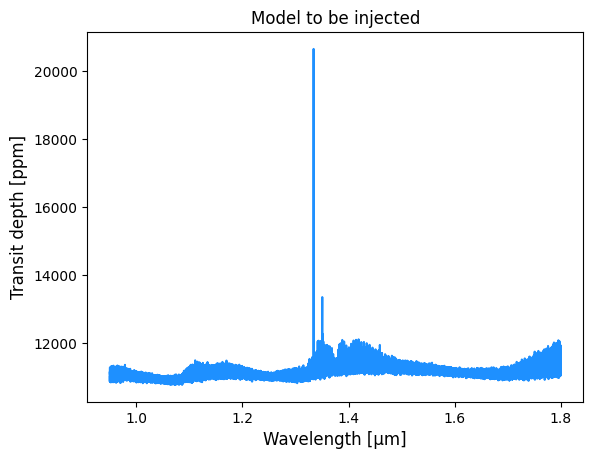

In [5]:
# INFORMATION
pl_name = "WASP-127 b"
instrument = "NIRPS"

# PARAMETERS OF THE PLANET
ap     = 0.04840*u.au       # semi-major axis of planet
R_star = 1.333*u.R_sun      # radius of star
R_pl   = 14.69*u.R_earth    # radius of planet
M_star = 0.950*const.M_sun  # mass of star
e      = 0                  # eccentricity
w      = 4.712389*u.rad     # argument of periapsis (equal to 270 degrees)

# MODEL TO INJECT
model_directory = "/home/mathisb/Github/HRS_models/"
model_filename = "prt_model_WASP-127b_H2O_v01.npz"  # npz file

scaling = 90  # scaling factor to multiply the model (transit depth) with     (max 3000 for CO2, 830 for H2O)
RV_inj = -75  # RV where to inject the signal

#----------------------------------------------------------------#

model_name = '_'.join(model_filename[:-4].split('_')[-2:])
model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

# Reduction version
reduction = f"injected_{model_name}_at{RV_inj}_scaling{scaling}"

# Plot it
plt.plot(wave_mod, model_spec * 1e6, color="dodgerblue")

plt.xlabel('Wavelength [μm]', fontsize=12)
plt.ylabel('Transit depth [ppm]', fontsize=12)  # transit depth: $(\frac{R_{\rm p}}{R_{\rm \star}})^2$
plt.title('Model to be injected')
plt.show()

In [6]:
# SOME IMPORTANT DICTIONARIES

# Lists of data files
list_filenames = {'list_e2ds': 'list_e2ds_2023-03-10-00',
                  'list_tcorr': 'list_tcorr_2023-03-10-00'}

# Data required for the injection
config_dict = {
                "instrument" : instrument,
                "reduction" : reduction,
                'scaling_factor' : scaling,
                'RV_inj' : RV_inj,
              }

## Run the injection

In [7]:
# Where to inject a signal
nightlist = [
            "2023-03-11"
               ]

# Where to save the injected data files
save_dir = None  # if None, saved in scratch/HRS_reductions/{instrument}/{planet}/injected/{visit_name}/{reduction}

#---------------------------------------------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print all the log information

obs_dict = {}

for visit_name in nightlist:
    # Directory where the data is
    obs_dir = "/home/mathisb/projects/def-rdoyon/shared/STARSHIPS_Workshop/WASP127b_night1/"
    config_dict['obs_dir'] = obs_dir
    
    # Create obs and planet objects
    obs = Observations(name=pl_name, 
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'excent': e,
                                'w': w},
                      instrument='NIRPS-APERO')

    obs.fetch_data(obs_dir, **list_filenames, CADC=True)
    p = obs.planet
    
    obs_dict[visit_name] = obs
    
    # Inject
    inj_rec(config_dict, p, obs, visit_name, wave_mod, model_spec, save_dir=save_dir, debug=False, debug2=False)


pl_obs.log.setLevel("INFO")  # go back to normal log printing

### Finding out the max scaling I can use with a model

In [8]:
find_max_scale = False
scaling_test = 90

if find_max_scale:
    # Plot the model

    # Model tr depth - tr depth of bare rock
    mod_spec_above0 = model_spec - (p.R_pl / p.R_star)**2
    plt.plot(wave_mod, mod_spec_above0 * 1e6, color="darkblue")
    plt.title("Original model minus transit depth of bare rock")
    plt.ylabel("ppm")
    plt.show()

    # The above but with scaling
    mod_spec_above0_scaled = mod_spec_above0 * scaling_test
    plt.plot(wave_mod, mod_spec_above0_scaled * 1e6, color="g")
    plt.hlines(1e6, wave_mod.min(), wave_mod.max(), ls="--", color="r", label="Do not go over this")
    plt.title("Scaled model")
    plt.ylabel("ppm")
    plt.show()

# Reduction

## Run the reduction

In [8]:
# PARAMETERS TO CHANGE

RVsys = [-8.94]  # RV of star system [km/s]
kind_trans = 'transmission'  # emission or transmission
coeffs = [0.02703969, 1.10037972, -0.96372403, 0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'

nPC = [0]  # number of principal components to remove
tellu_frac = 0.40  # telluric fraction to mask (usually varied between 0.2 and 0.5)
mask_wings = 0.97  # fraction of wings of deep tellurics to mask

#---------------------------------------------------------------------------------#

# Fixed parameters
cbp = True  # correct bad pixels
iout_all = ['all']
polynome = [False] 
do_tr = [1]
transit_tags = [None]  # use if want to remove spectra

kwargs_gen_tr = {
    'coeffs' : coeffs,
    'ld_model' : ld_model,
    'do_tr' : do_tr,
    'kind_trans' : kind_trans,
    'polynome' : polynome,
    'cbp': cbp }

kwargs_build_ts = {
    'clip_ratio' : 6,
    'clip_ts' : 6,
    'unberv_it' : True }

obs_dict_inj = {}

pl_obs.log.setLevel("WARNING")  # do not print all the log information


for visit_name in nightlist:
    
    # Where to output the reductions
    pl_name_fname = ''.join(pl_name.split())
    out_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')
    # out_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/v001')  # FOR A NORMAL REDUCTION
    out_dir.mkdir(parents=True, exist_ok=True)  # make sure the directory exists
    
    # Directory with the injected data files
    obs_dir = f"/home/mathisb/scratch/HRS_reductions/{instrument}/{pl_name_fname}/injected/{visit_name}/{reduction}"
    # obs_dir = "/home/mathisb/projects/def-rdoyon/shared/STARSHIPS_Workshop/WASP127b_night1/"  # FOR A NORMAL REDUCTION
    
    # Where to save figures
    path_fig = out_dir / Path('Figures/')
    path_fig.mkdir(parents=True, exist_ok=True)  # make sure the  directory exists
    
    # Create obs_inj object
    obs = Observations(name=pl_name, 
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'excent': e,
                                'w': w},
                      instrument='NIRPS-APERO')

    obs.fetch_data(obs_dir, **list_filenames, CADC=True)
    obs_dict_inj[visit_name] = obs
    
    # Do the reduction
    for n_pc in nPC:
        params_all=[[tellu_frac, mask_wings, 51, 41, 5, n_pc, 5.0, 5.0, 5.0, 5.0]]
        list_tr = pl_obs.generate_all_transits(obs_dict_inj[visit_name], transit_tags, RVsys, params_all, iout_all, **kwargs_gen_tr, **kwargs_build_ts)

        # Save sequence with all reduction steps
        out_filename = f'sequence_{n_pc}-pc_mask_wings{mask_wings*100:n}'
        pl_obs.save_single_sequences(out_filename, list_tr['1'], path=out_dir, filename_end=visit_name, save_all=True)

        # Save sequence with only the info needed for a retrieval (to compute log likelihood)
        out_filename = f'retrieval_input_{n_pc}-pc_mask_wings{mask_wings*100:n}'
        pl_obs.save_sequences(out_filename, list_tr, do_tr, path=out_dir)
    

pl_obs.log.setLevel("INFO")  # go back to normal log printing


## Plot the reduction

In [9]:
# LOAD ALL THE REDUCTIONS

# If needed, specify the nights, nPC and mask_wings to plot (otherwise None)
night_plot = None
nPC_plot = None
mask_wings_plot = None

#----------------------------------#

night_plot = night_plot or nightlist
nPC_plot = nPC_plot or nPC
mask_wings_plot = mask_wings_plot or [int(mask_wings * 100)]

seq_files = [
    f"sequence_{n}-pc_mask_wings{m}_data_trs_{visit}.npz"
    for visit in night_plot
    for n in nPC_plot
    for m in mask_wings_plot
]

# Load all sequence objects and put them in a list
seq_obj_list = []

for seq in seq_files:
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    print(f"Loading {seq_visit} |", f"{seq[:-4].split('_')[1]}, {seq[:-4].split('_')[2]}" + f"_{seq[:-4].split('_')[3]}")

    path_reduc = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{seq_visit}/{reduction}')
    seq_obj_list.append(pl_obs.load_single_sequences(seq, name=pl_name, planet=p, path=path_reduc, load_all=True, plot=False))

print("Done")

Loading 2023-03-11 | 0-pc, mask_wings97
Done


Reduction steps: 2023-03-11


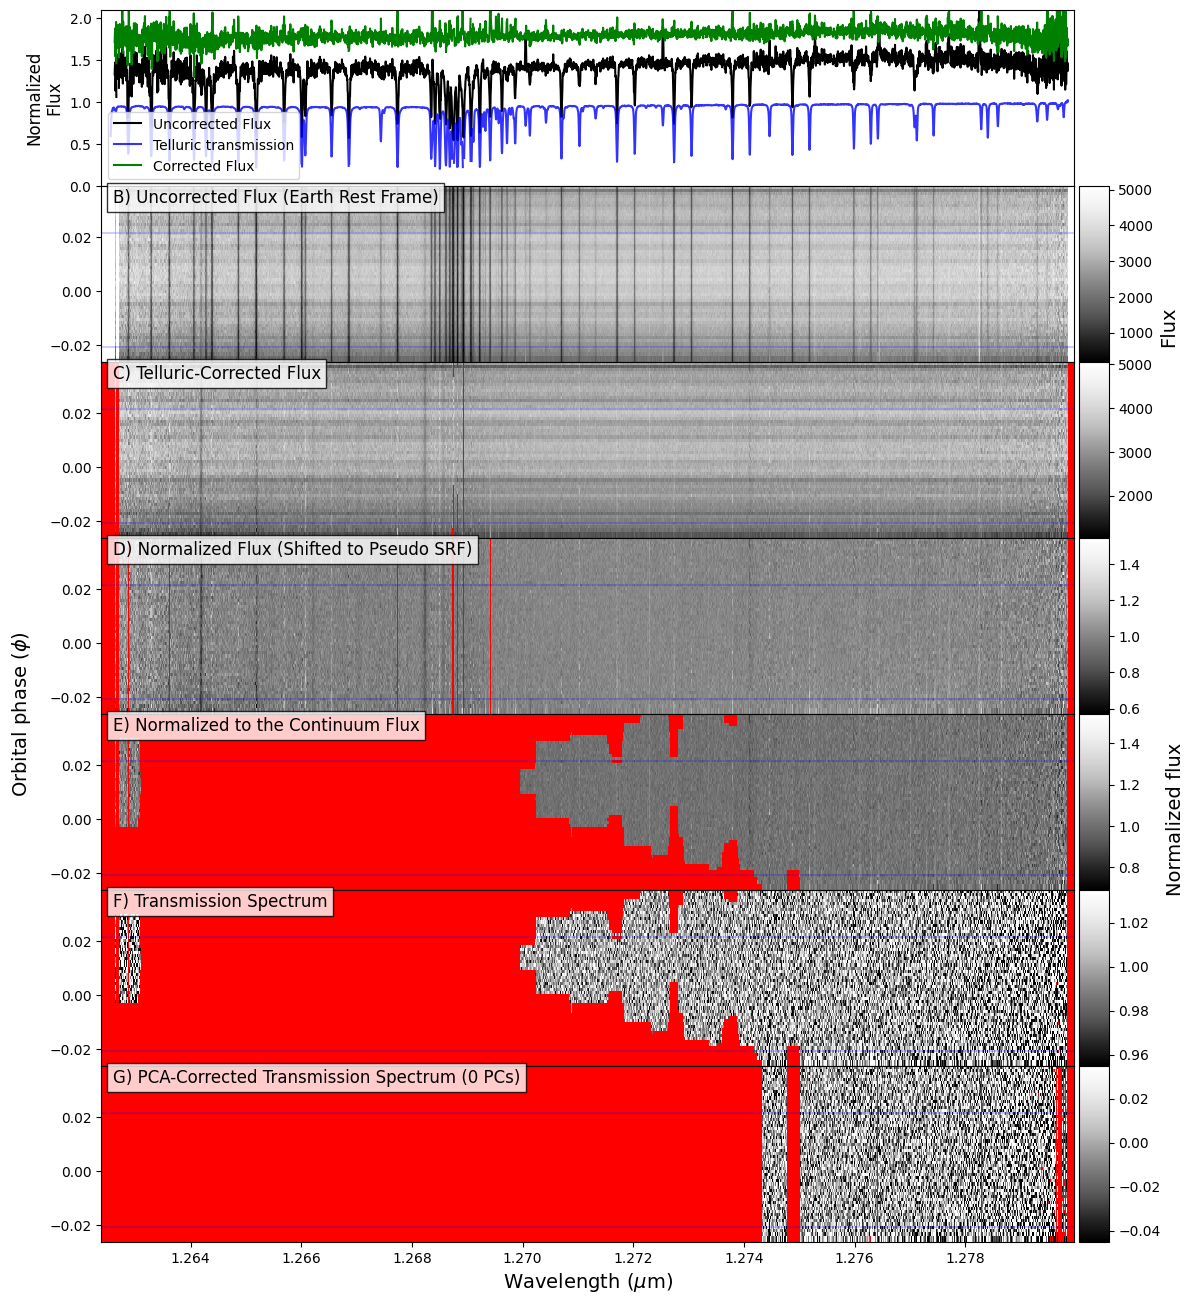

In [10]:
# PLOT THE REDUCTION STEPS

# Order to plot
order_plot = 36

#--------------#

for i, seq in enumerate(seq_files):
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    print(f'\033[1mReduction steps: {seq_visit}\033[0m')
    plot_steps = pf.plot_steps(seq_obj_list[i], order_plot - 1)


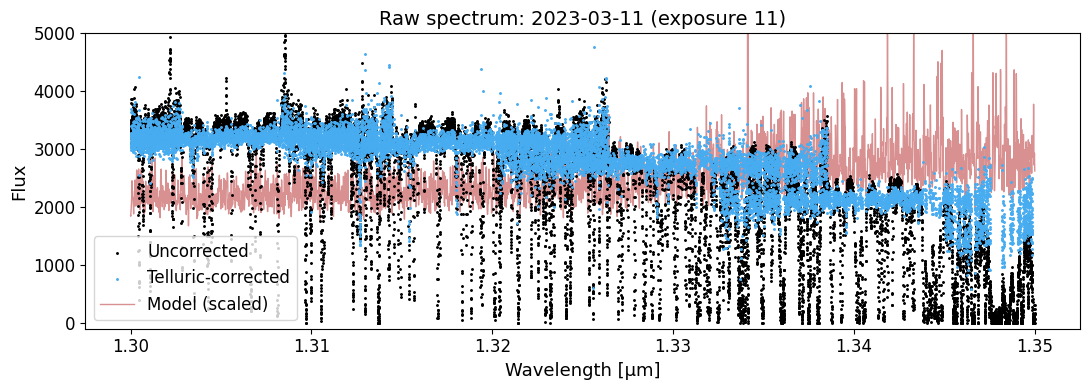

In [11]:
# PLOT RAW AND TELLURIC-CORRECTED SPECTRUM WITH OVERLAPPING ORDERS

wv_range = [1.3, 1.35]  # wavelength range to plot, in microns

use_median = False  # plot the median flux of all exposures
exp_plot = 11  # exposure to plot (ignored if use_median = True)

compare_model = True  # plot model as backdrop, to compare

ylims = [-100, 5000]  # specify y axis limits

#--------------------------------------------#

plotted_visits = []  # keep track of visits already plotted
mod_spec_zero = model_spec - (p.R_pl / p.R_star) **2  # model with transit depth of bare rock subtracted

for i, seq in enumerate(seq_files):
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    
    if seq_visit in plotted_visits:
        continue
    
    pf.plot_raw_spectrum(seq_obj_list[i], wv_range, seq_visit, use_median=use_median, exp_plot=exp_plot,
                         compare_model=compare_model, model_wav=wave_mod, model_spec=mod_spec_zero, ylims=ylims)
    plotted_visits.append(seq_visit)


### Plot of data vs model * out-of-transit flux

In [12]:
def plot_for_Nic(observation, wv_range, visit_name, use_median=True, exp_plot=10, compare_model=False, model_wav=None, model_spec=None, ylims=None):
    # ----------------------- sanity checks ----------------------------- #
    if wv_range[0] >= wv_range[1]:
        raise ValueError("wavelength_range must be (min, max) with min < max.")

    if not use_median and not (1 <= exp_plot < observation.uncorr.shape[0]):
        raise IndexError("exp_plot is out of bounds for the number of exposures.")
        
    if compare_model and (model_wav is None or model_spec is None):
        raise ValueError("model_wav and model_spec must be given when compare_model=True.")

    # -------------------- blaze‑function correction -------------------- #
    # Divide by the blaze to get a spectrum normalized at 1
    blaze_norm = observation.blaze / np.nanmax(observation.blaze, axis=-1, keepdims=True)
    uncorrected_flux = observation.uncorr / blaze_norm

    # ------------------ build 1‑D concatenated spectra ----------------- #
    order_indices = np.arange(observation.nord)  # array with all the orders

    # Concatenate wavelength values across orders
    wavelength = np.concatenate([observation.wv[i] for i in order_indices])

    if use_median:
        # Median across exposures, order by order
        flux_uncorrected = np.concatenate([np.nanmedian(uncorrected_flux, axis=0)[i] for i in order_indices])
        flux_corrected = np.concatenate([np.nanmedian(observation.flux, axis=0)[i] for i in order_indices])
    else:
        flux_uncorrected = np.concatenate([uncorrected_flux[exp_plot - 1, i] for i in order_indices])
        flux_corrected = np.concatenate([observation.flux[exp_plot - 1, i] for i in order_indices])

    # ----------------------- wavelength mask --------------------------- #
    mask = (wv_range[0] < wavelength) & (wavelength < wv_range[1])
    
    # ---------------------------- plot --------------------------------- #
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.scatter(wavelength[mask], flux_corrected[mask], s=1.2, c="#48ACF0", label="Telluric‑corrected",zorder=4)
    
    # --------------- optional model backdrop --------------------------- #
    if compare_model:
        # Mask model to requested wavelength range
        model_mask = (wv_range[0] < model_wav) & (model_wav < wv_range[1])
        model_wav_in = model_wav[model_mask]
        model_spec_in = model_spec[model_mask]
        
        # Interpolate model to data wavelength grid
        interp_func = interp1d(model_wav_in, model_spec_in, kind='cubic', bounds_error=False, fill_value="extrapolate")
        interp_model_spec = interp_func(wavelength[mask])
        
        flux_outoftr = np.concatenate([observation.flux[1, i] for i in order_indices])
        
        model_times_Fout = interp_model_spec * flux_outoftr[mask]
        
        ax.plot(wavelength[mask], model_times_Fout, color="firebrick", linewidth=1, alpha=0.5,
                label="Model (scaled) * F_out", zorder=0)

    # --------------- labels, limits, legend ---------------------------- #
    ax.set_xlabel("Wavelength [μm]", fontsize=13)
    ax.set_ylabel("Flux", fontsize=13)

    # Plot title
    if use_median:
        title = f"Raw spectrum: {visit_name} (median of exposures)"
    else:
        title = f"Raw spectrum: {visit_name} (exposure {exp_plot})"
    
    # Set limits for the y axis
    if ylims is not None:
        ax.set_ylim(ylims)
    
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.show()
    


def plot_inj_data(observation, noninj_data, wv_range, visit_name, use_median=True, exp_plot=10, ylims=None):
    # ----------------------- sanity checks ----------------------------- #
    if wv_range[0] >= wv_range[1]:
        raise ValueError("wavelength_range must be (min, max) with min < max.")

    if not use_median and not (1 <= exp_plot < observation.uncorr.shape[0]):
        raise IndexError("exp_plot is out of bounds for the number of exposures.")

    # -------------------- blaze‑function correction -------------------- #
    # Divide by the blaze to get a spectrum normalized at 1
    blaze_norm = observation.blaze / np.nanmax(observation.blaze, axis=-1, keepdims=True)
    uncorrected_flux = observation.uncorr / blaze_norm
    
    # SAME BUT FOR NONINJ DATA
    blaze_norm_noninj = noninj_data.blaze / np.nanmax(noninj_data.blaze, axis=-1, keepdims=True)
    uncorrected_flux_noninj = noninj_data.uncorr / blaze_norm_noninj

    # ------------------ build 1‑D concatenated spectra ----------------- #
    order_indices = np.arange(observation.nord)  # array with all the orders

    # Concatenate wavelength values across orders
    wavelength = np.concatenate([observation.wv[i] for i in order_indices])

    if use_median:
        # Median across exposures, order by order
        flux_uncorrected = np.concatenate([np.nanmedian(uncorrected_flux, axis=0)[i] for i in order_indices])
        flux_corrected = np.concatenate([np.nanmedian(observation.flux, axis=0)[i] for i in order_indices])
        
        # SAME BUT FOR NONINJ DATA
        flux_uncorrected_noninj = np.concatenate([np.nanmedian(uncorrected_flux_noninj, axis=0)[i] for i in order_indices])
        flux_corrected_noninj = np.concatenate([np.nanmedian(noninj_data.flux, axis=0)[i] for i in order_indices])
        
    else:
        flux_uncorrected = np.concatenate([uncorrected_flux[exp_plot - 1, i] for i in order_indices])
        flux_corrected = np.concatenate([observation.flux[exp_plot - 1, i] for i in order_indices])
        
        # SAME BUT FOR NONINJ DATA
        flux_uncorrected_noninj = np.concatenate([uncorrected_flux_noninj[exp_plot - 1, i] for i in order_indices])
        flux_corrected_noninj = np.concatenate([noninj_data.flux[exp_plot - 1, i] for i in order_indices])

    # ----------------------- wavelength mask --------------------------- #
    mask = (wv_range[0] < wavelength) & (wavelength < wv_range[1])
    
    # ---------------------------- plot --------------------------------- #
    fig, ax = plt.subplots(figsize=(11, 4))
    # ax.scatter(wavelength[mask], flux_uncorrected[mask], s=1.2, c="#21eb8c", label="Injected data", zorder=3)
    # ax.scatter(wavelength[mask], flux_uncorrected_noninj[mask], s=1.2, c="k", label="Non-injected data", zorder=2)
    
    ax.scatter(wavelength[mask], flux_uncorrected[mask] - flux_uncorrected_noninj[mask], s=1.2, c="r", label="Injected data − non-injected data", zorder=2)

    # --------------- labels, limits, legend ---------------------------- #
    ax.set_xlabel("Wavelength [μm]", fontsize=13)
    ax.set_ylabel("Flux", fontsize=13)

    # Plot title
    if use_median:
        title = f"Injected vs raw spectrum: {visit_name} (median of exposures)"
    else:
        title = f"Injected vs raw spectrum: {visit_name} (exposure {exp_plot})"
    
    # Set limits for the y axis
    if ylims is not None:
        ax.set_ylim(ylims)
    
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.show()


In [13]:

do_plot_for_Nic = False

wv_range = [1.5, 1.63]  # wavelength range to plot, in microns

use_median = False  # plot the median flux of all exposures
exp_plot = 9  # exposure to plot (ignored if use_median = True)

compare_model = True  # plot model as backdrop, to compare

ylims = [-100, 5000]  # specify y axis limits

#--------------------------------------------#

if do_plot_for_Nic:
    plotted_visits = []  # keep track of visits already plotted
    model_to_plot = 1 - ((model_spec - (p.R_pl / p.R_star) **2) * scaling_test + (p.R_pl / p.R_star) **2)

    for i, seq in enumerate(seq_files):
        seq_visit = seq[:-4].split('_')[-1]  # get the visit name

        if seq_visit in plotted_visits:
            continue

        plot_for_Nic(seq_obj_list[i], wv_range, seq_visit, use_median=use_median, exp_plot=exp_plot,
                             compare_model=compare_model, model_wav=wave_mod, model_spec=model_to_plot, ylims=ylims)
        plotted_visits.append(seq_visit)


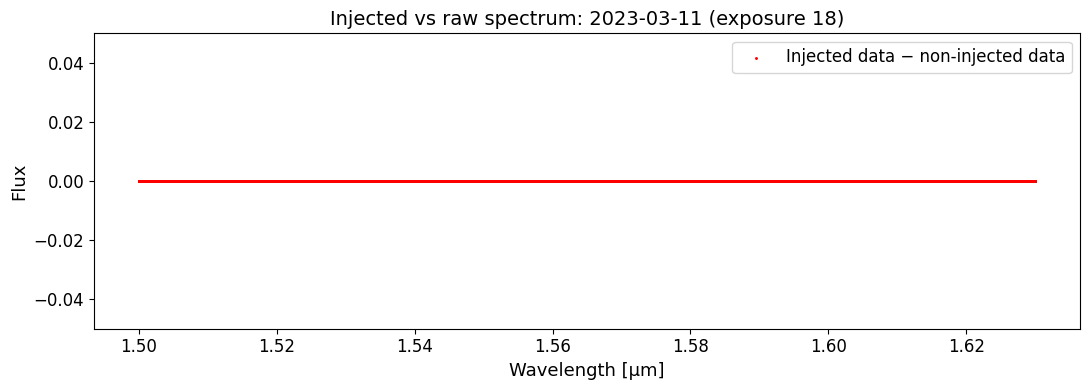

In [14]:

do_plot_inj_data = True

wv_range = [1.5, 1.63]  # wavelength range to plot, in microns

use_median = False  # plot the median flux of all exposures
exp_plot = 18  # exposure to plot (ignored if use_median = True)

ylims = [-0.05, 0.05]  # specify y axis limits

#--------------------------------------------#

if do_plot_inj_data:
        plotted_visits = []  # keep track of visits already plotted

        for seq in seq_files:
            seq_visit = seq[:-4].split('_')[-1]  # get the visit name

            if seq_visit in plotted_visits:
                continue
            
            # Fetch the non injected data
            path_reduc_noninj = Path('/home/mathisb/scratch/HRS_reductions/NIRPS/WASP-127b/2023-03-11/v001/')
            noninj_data = pl_obs.load_single_sequences(seq, name=pl_name, planet=p, path=path_reduc_noninj, load_all=True, plot=False)
            
            plot_inj_data(seq_obj_list[i], noninj_data, wv_range, seq_visit, use_median=use_median, exp_plot=exp_plot, ylims=ylims)
            plotted_visits.append(seq_visit)

# Correlations

## Run the correlations

In [19]:
# Define cross-correlation axes
n_RV_inj = 151  # number of RV steps
corr_xlim = 150  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

#-------------------------------------------------------------------------------------#

# Correlation setup
corrRV0 = np.linspace(-corr_xlim, corr_xlim, n_RV_inj)  # x axis (Vrad)

n_pc_list = []
mask_wings_list = []
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()


# Run the correlation
for seq in seq_files:
    
    # Filenames and paths
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    path_reduc = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{seq_visit}/{reduction}')  # where to find the reductions
    path_corr = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{seq_visit}/{reduction}')  # where to output the correlations
    path_corr.mkdir(parents=True, exist_ok=True)  # create output directory if it does not exist
    
    # Load the observation
    obs = pl_obs.load_single_sequences(seq, pl_name, planet=p, path=path_reduc, load_all=False, filename_end='', plot=False)

    # Generate Kp 
    Kp_array = np.array([obs.Kp.value]) 

    n_pc = int(obs.params[5])
    n_pc_list.append(n_pc)

    mask_wings = int(obs.params[1] * 100)
    mask_wings_list.append(mask_wings)

    out_filename = f'{Path(seq).stem}_ccf_logl_seq_{model_name}'

    try:
        # Check if already generated
        saved_values = np.load(path_corr / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
        print(seq, ": CCF already generated")

    except FileNotFoundError:
        # Generate 1d correlations
        # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs, 'seq', p, Kp_array, corrRV0,
                                                  [n_pc], wave_mod, model_spec, kind_trans)
        
        # Save the correlation in a file
        corr.save_logl_seq(path_corr / Path(out_filename), ccf_map, logl_map,
                           wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)

    all_obs[(seq_visit, n_pc, mask_wings)] = obs
    all_ccf_map[(seq_visit, n_pc, mask_wings)] = ccf_map
    all_logl_map[(seq_visit, n_pc, mask_wings)] = logl_map
    

Injecting model w/ alpha = ones
Starting with 0 PCs
Computing with
Saved correl at : /scratch/mathisb/HRS_correlations/NIRPS/WASP-127b/2023-03-11/injected_H2O_v01_at-75_scaling90/sequence_0-pc_mask_wings97_data_trs_2023-03-11_ccf_logl_seq_H2O_v01.npz


## Plot the correlations

Max value at 0 nPC = 0.08738115655092152 at -7.888907289329292 km/s
Max value at 0 nPC = 0.19960752398605566 at -7.694392462108604 km/s
Max value at 0 nPC = 0.19960752398605566 at -7.694392462108604 km/s


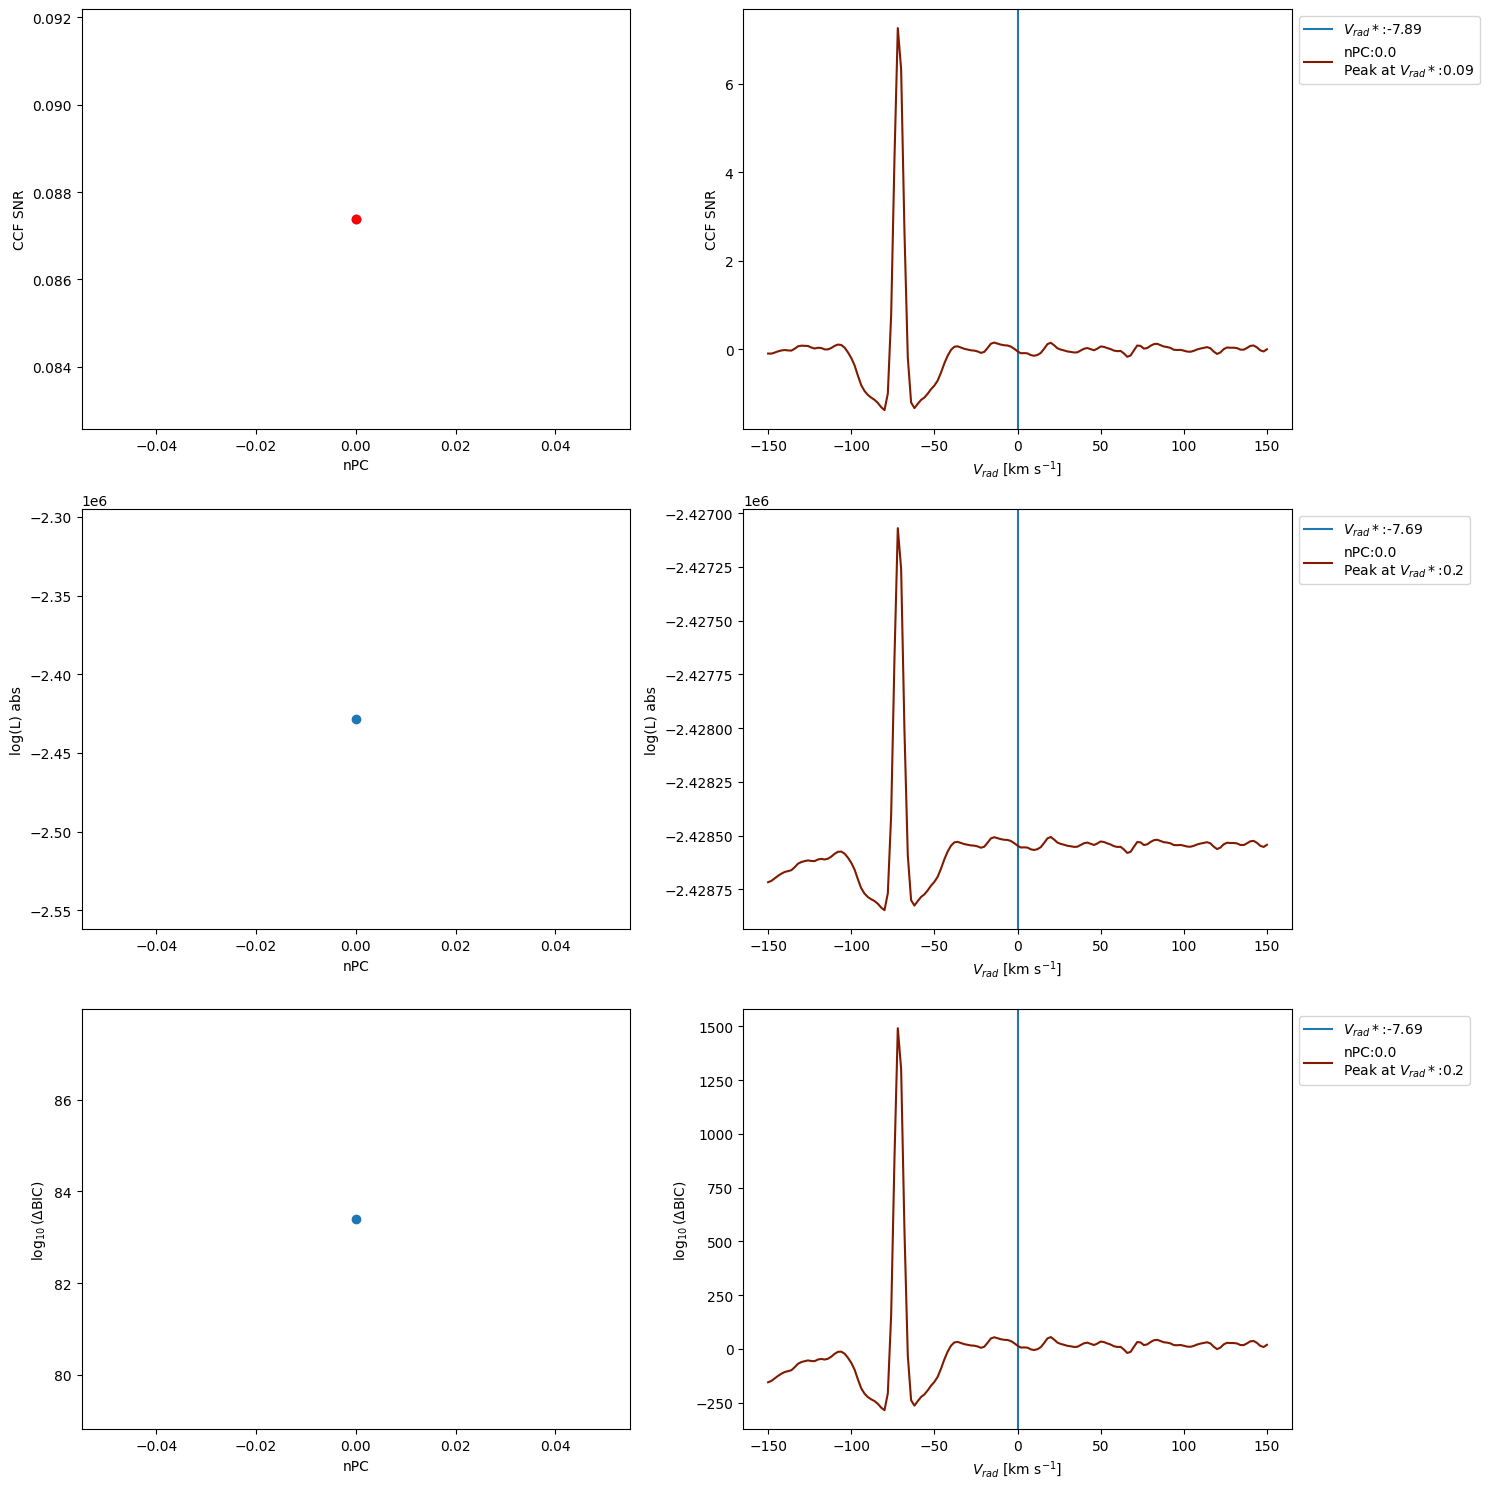

CCF SNR peak at Vrad*: [0.08738116]
log(L) abs peak at Vrad*: [-2428519.3425078]
log_10(ΔBIC) peak at Vrad*: [83.39416664]
(56, 151)
Saved file to :  /scratch/mathisb/HRS_correlations/NIRPS/WASP-127b/2023-03-11/injected_H2O_v01_at-75_scaling90/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2023-03-11_ccf_logl_seq_H2O_v01_pc0.pdf
(array([53, 54]),)
In-transit t-val = -0.02 / p-val 9.81e-01 / sig = -2.07
Out-of-transit t-val = 1.32 / p-val 1.94e-01 / sig = 0.86


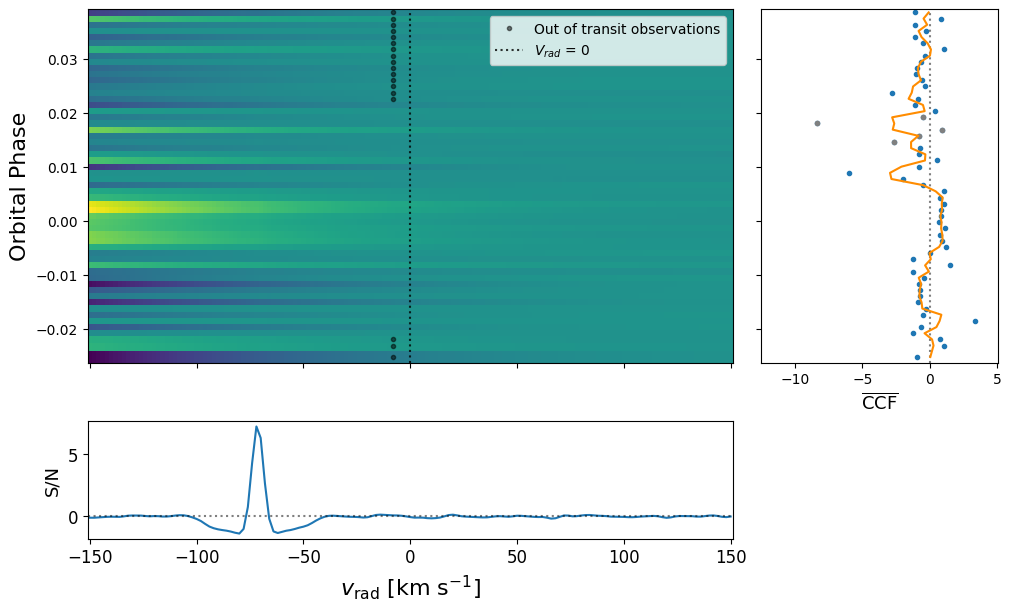

In [20]:
# List of nights to plot
nights_plot = [
            "2023-03-11"
               ]

# OPTIONAL: plot a specific reduction
# If None, shows best nPC and mask_wings values for the nights in nights_plot
n_pc_plot = None
mask_wings_plot = None


# Indices of orders that should not be used in the plots
orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]]

#-------------------------------------------------------------------------------------#

order_indices = np.arange(obs.nord)  # array of orders

# Remove each element of orders_to_delete from array of orders
for elem in orders_to_delete:
    order_indices = np.setdiff1d(order_indices, elem)

for visit_name in nights_plot:
    
    path_reduc = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')  # where to find the reductions
    fig_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}/{reduction}/Figures/')  # where to put the figures
    fig_dir.mkdir(parents=True, exist_ok=True)  # create figures directory if it does not exist
    
    if n_pc_plot is None or mask_wings_plot is None:  # if both nPC and mask_wings have not been specified
        
        n_pc_list = np.unique(n_pc_list)
        n_pc_str = '-'.join(str(i) for i in n_pc_list)
        mask_wings_list = np.unique(mask_wings_list)
        mask_wings_str = '-'.join(str(i) for i in mask_wings_list)

        id_pc0 = 0  # don't change

        # Plot all ccf and logl as a function of nPC and mask_wings
        ccf_maps_in = np.concatenate([all_ccf_map[(visit_name, n, m)] for n in n_pc_list for m in mask_wings_list], axis=-2)
        logl_maps_in = np.concatenate([all_logl_map[(visit_name, n, m)] for n in n_pc_list for m in mask_wings_list], axis=-2)
        obs = all_obs[(visit_name, n_pc_list[0], mask_wings_list[0])]
        
        fig_name = f'sequence_{n_pc_str}-pc_mask_wings{mask_wings_str}_data_trs_{visit_name}_ccf_logl_seq_{model_name}'

        ccf_obj, logl_obj = cc.plot_ccflogl(obs, ccf_maps_in, logl_maps_in, corrRV0, Kp_array, n_pc_list,
                                            orders=order_indices, id_pc0=id_pc0, cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)
    
    else:
        # Reduction to plot
        seq_filename = f'sequence_{n_pc_plot}-pc_mask_wings{mask_wings_plot}_data_trs_{visit_name}.npz'
    
        # Plot single ccf and logl
        obs = pl_obs.load_single_sequences(seq_filename, pl_name, path=path_reduc, load_all=False, filename_end='', plot=False, planet=p)

        fig_name = f'sequence_{n_pc_plot}-pc_mask_wings{mask_wings_plot}_data_trs_{visit_name}_ccf_logl_seq_{model_name}'
        
        args = [all_something[(visit_name, n_pc, mask_wings)] for all_something in [all_obs, all_ccf_map, all_logl_map]]
        ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc_plot], orders=order_indices,
                                            cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=out_filename)
    

T-test map & distributions of CC values: 2023-03-11 | nPC=0, mask_wings=0.97
T-val : Max value = -0.0 // Max position = -5.0
Histogram for Kp = 129.84 and RV = -7.89


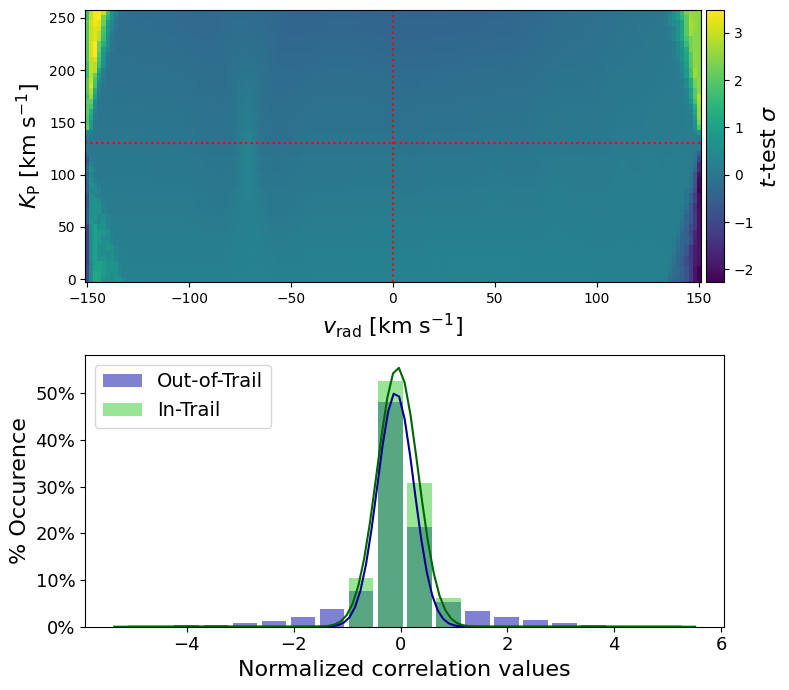

<Figure size 640x480 with 0 Axes>

-0.03796688922181407 0.9697679850440303 -1.8773946083757156
All orders: 2023-03-11 | nPC=0, mask_wings=0.97


UnboundLocalError: local variable 'fg_color' referenced before assignment

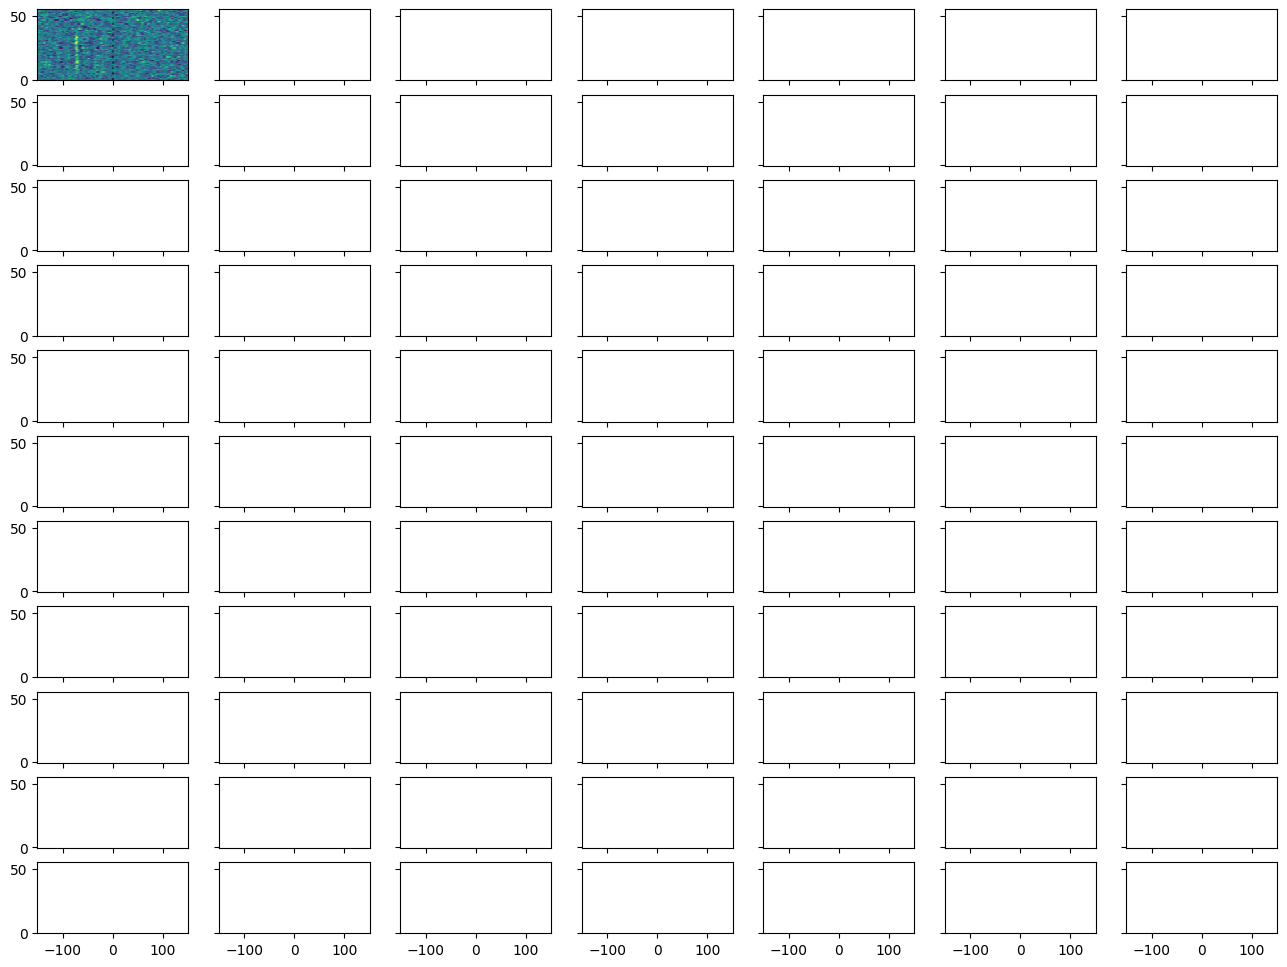

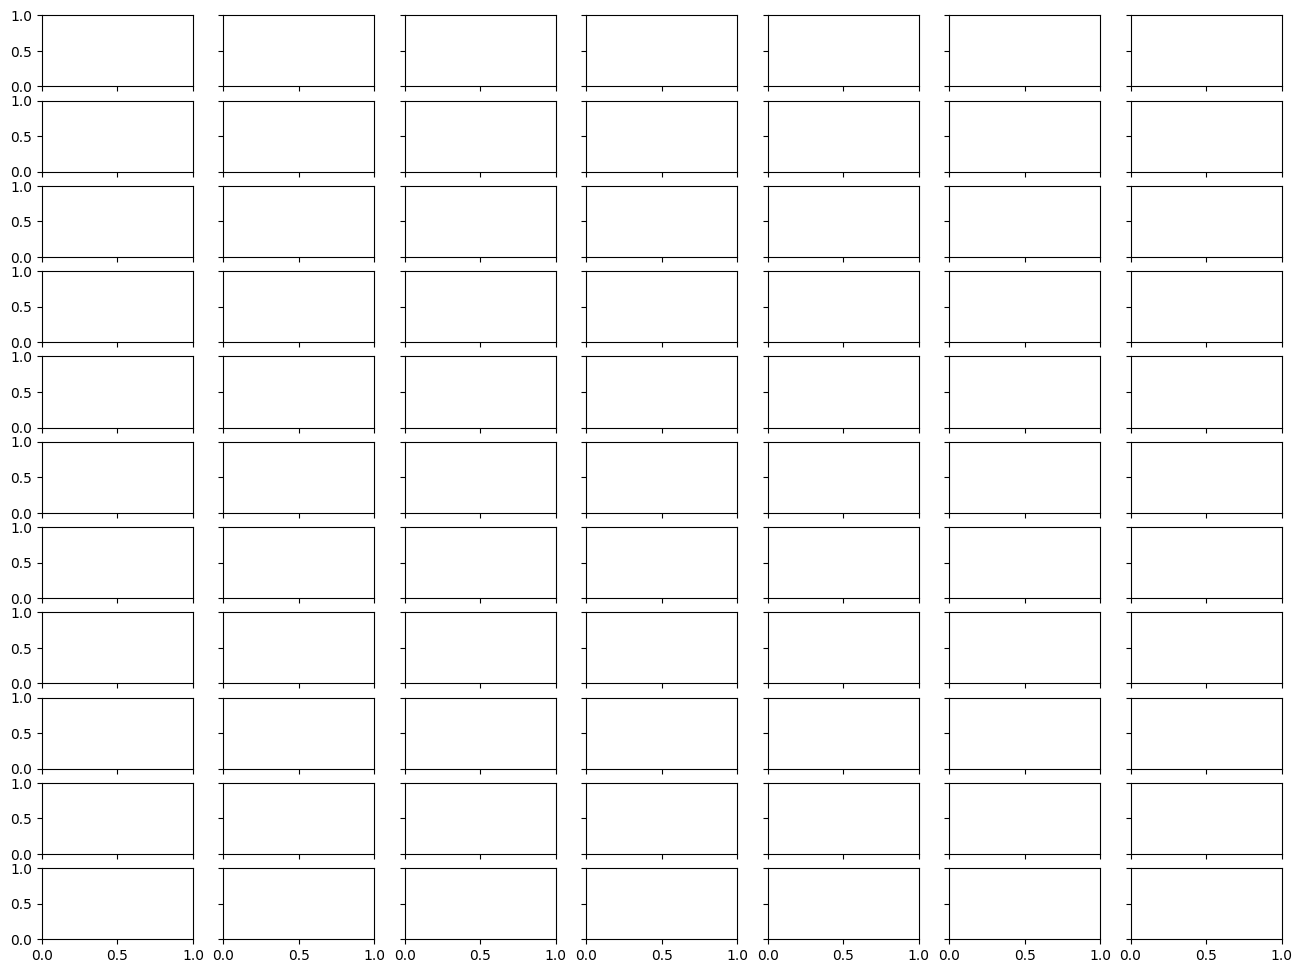

In [23]:
# PLOT T-TEST MAP AND DISTRIBUTIONS OF CROSS-CORRELATION VALUES
# OPTIONAL: PLOT ALL ORDERS

plot_all_orders = True  # plot the correlation map for each order

#---------------------------------------------------------------#

for visit_name in nights_plot:
    
    # Build the list of (npc, mask, obs) to plot for this night
    if n_pc_plot is not None and mask_wings_plot is not None:  # plot a single reduction
        combos = [(n_pc_plot,
                   mask_wings_plot,
                   all_obs[(visit_name, n_pc_plot, mask_wings_plot)])]
    else:                                                      # plot all reductions
        combos = [(npc, maskwings, obs)
                  for (visit, npc, maskwings), obs in all_obs.items()
                  if visit == visit_name]
    
    # Loop once over whatever we decided to plot
    for npc, maskwings, obs in combos:
        print(f"\033[1mT-test map & distributions of CC values: {visit_name} | "
              f"nPC={npc}, mask_wings={maskwings/100:.2f}\033[0m")
        ccf_obj.ttest_map(obs, kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                      kp0=0, RV_limit=corr_xlim, kp_step=5, rv_step=2, RV=None, speed_limit=3, icorr=obs.iIn, equal_var=False)
        
        if plot_all_orders:
            print(f"\033[1mAll orders: {visit_name} | "
                  f"nPC={npc}, mask_wings={maskwings/100:.2f}\033[0m")
            pf.plot_all_orders_correl(corrRV0, ccf_obj.data.squeeze(), obs, icorr=None, logl=False, sharey=True,
                              vrp=np.zeros_like(obs.vrp), RV_sys=0.0, vmin=None, vmax=None, vline=None,
                              hline=2, kind='snr', return_snr=False, orders=order_indices)


## Combined

In [10]:
# PARAMETERS FOR THE COMBINED CORRELATION

nPC = 0  # nPC to use

# Nights to combine
file_arr = np.array([
                    ['1', '2019-06-14', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-06-14.npz'],
                    ['2', '2019-09-25', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-09-25.npz'],
                    ['3', '2020-05-31', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-05-31.npz'],
                    ['4', '2020-08-04', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-08-04.npz'],
                    ['5', '2020-09-08', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-08.npz'],
                    ['6', '2020-09-20', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-20.npz'],
                    ['7', '2020-09-26', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-26.npz'],
                    ['8', '2020-09-29', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-29.npz'],
                    ['9', '2021-10-21', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-21.npz'],
                    ['10', '2021-10-24', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-24.npz'],
                    ['11', '2021-10-27', reduction, f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-27.npz'],
                    ])

# Reduction parameters
kind_trans = 'transmission'  # emission or transmission
coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'

# Define cross-correlation axes
step_RV_inj = 2.14  # 2 times the resolution of SPIRou in km/s
corr_xlim = 150  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

#-------------------------------------------------------------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print entire log in this cell

# Correlation setup
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
combined_ccf = []
combined_logl = []
combined_obs = []
visit_dict = dict()
all_visits_str = ""

for reduc_idx, reduc in enumerate(file_arr):
    
    visit_nb = reduc[0]
    visit = reduc[1]
    version = reduc[2]
    fname = reduc[3]
    
    print("Loading", visit, "correlation...")
    
    # Where to find the reductions
    reduc_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit}/{version}')
    
    # Where to find the correlations
    corr_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit}/{version}')
    
    # Redefine planet (since mid-tr time changes for each visit)
    mid_tr = mid_tr_dict[visit]

    pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'mid_tr': mid_tr,
                 'excent': e,
                 'w': w}

    planet_obj = Planet(pl_name, **pl_kwargs)
    
    obs = pl_obs.load_single_sequences(fname, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)
    
    out_filename = f'{Path(fname).stem}_ccf_logl_seq_{model_name}'
    
    try:
        # Check if already generated
        saved_values = np.load(corr_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
        
    except FileNotFoundError:
        # Generate 1d correlations
        # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs,'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
    
        corr.save_logl_seq(corr_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    

    all_visits_str += visit_nb + "-"
    
    visit_dict[str(reduc_idx + 1)] = obs
    combined_obs.append(obs)
    combined_ccf.append(ccf_map)
    combined_logl.append(logl_map)


transit_tags = [np.arange(obs.n_spec) for obs in visit_dict.values()]
all_visits = pl_obs.gen_merge_obs_sequence(obs, visit_dict, np.arange(1, len(file_arr) + 1), None, coeffs, ld_model, kind_trans, light=True)

all_visits.dt = np.concatenate([vst.dt for vst in visit_dict.values()])  # exposition times

all_visits_str = all_visits_str[:-1]
visit_dict[all_visits_str.replace("-", "")] = all_visits

pl_obs.log.setLevel("INFO")  # go back to normal log printing


Loading 2019-06-14 correlation...
Loading 2019-09-25 correlation...
Loading 2020-05-31 correlation...
Loading 2020-08-04 correlation...
Loading 2020-09-08 correlation...
Loading 2020-09-20 correlation...
Loading 2020-09-26 correlation...
Loading 2020-09-29 correlation...
Loading 2021-10-21 correlation...
Loading 2021-10-24 correlation...
Loading 2021-10-27 correlation...


Max value at 0 nPC = 0.9031290777107244 at -6.6199964948244405 km/s


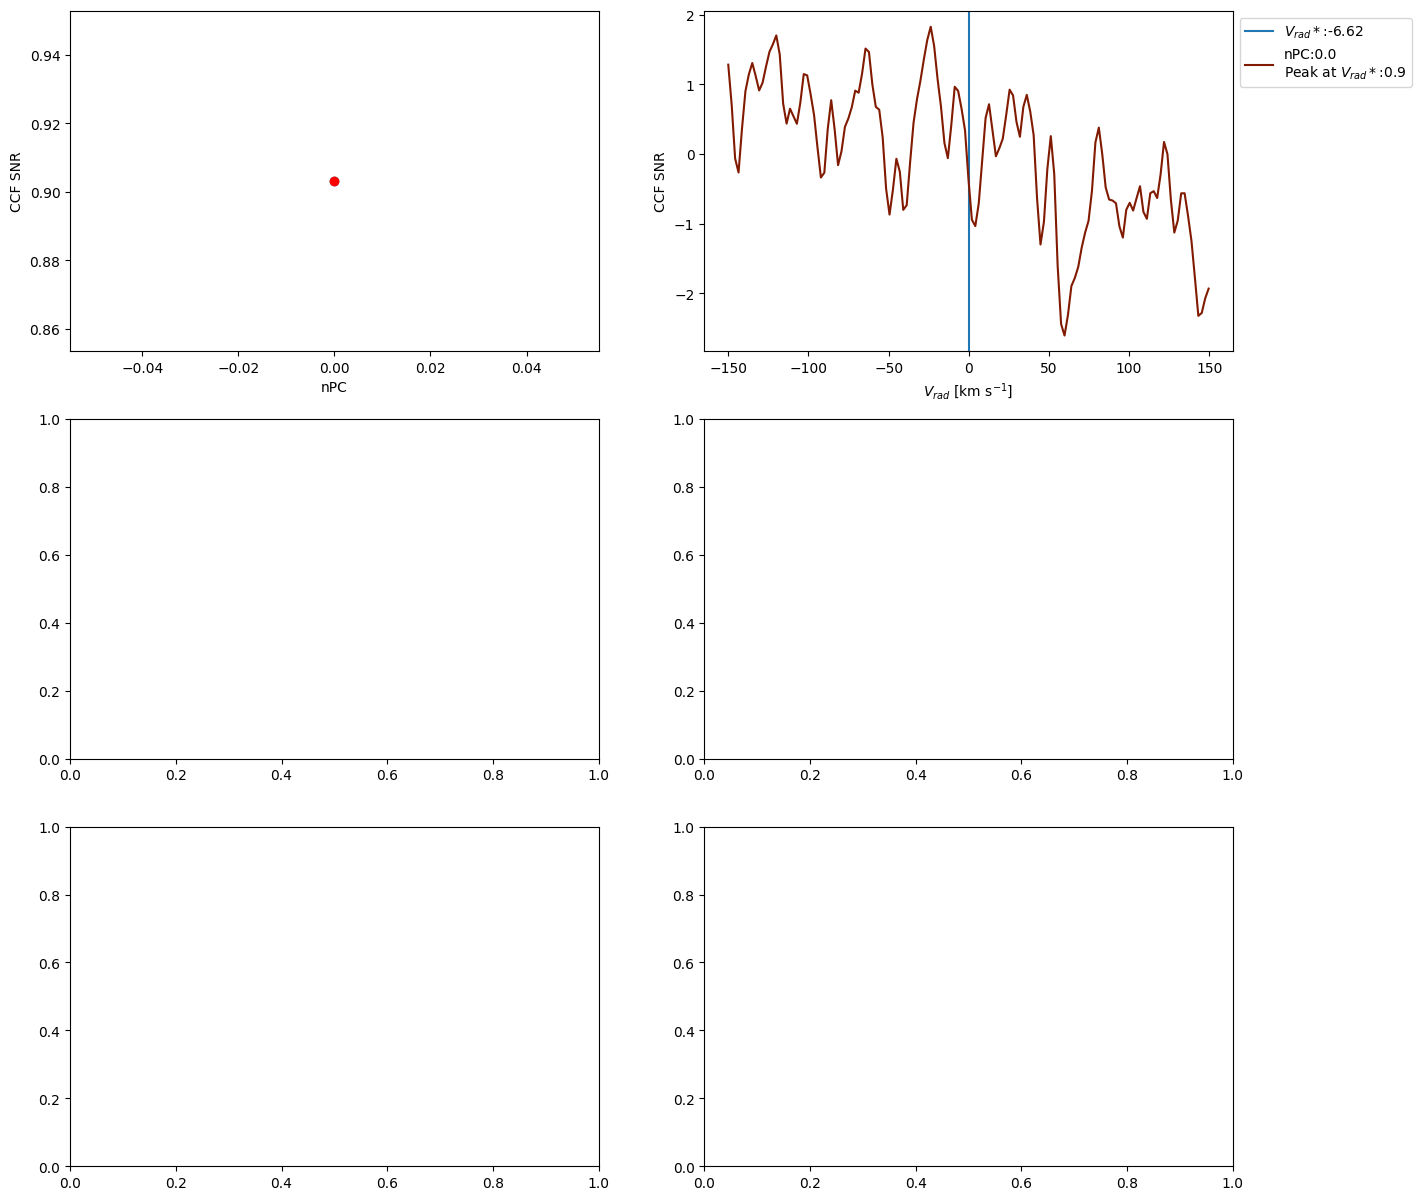

Max value at 0 nPC = 0.9019119873000739 at -6.619996538206624 km/s
Max value at 0 nPC = 0.9019119873000739 at -6.619996538206624 km/s
CCF SNR peak at Vrad*: [0.90312908]
log(L) abs peak at Vrad*: [-8625508.59288247]
log_10(ΔBIC) peak at Vrad*: [0.53872179]
[0.]
(170, 141)
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/Combined/injected_CO2_v05_at-75_scaling3000/Figures/fig_CCF_2Dcombined_corr_nights1-2-3-4-5-6-7-8-9-10-11_pc0-0-0-0-0-0-0-0-0-0-0_mask_wings97-97-97-97-97-97-97-97-97-97-97_CO2_v05_pc0.pdf


<Figure size 640x480 with 0 Axes>

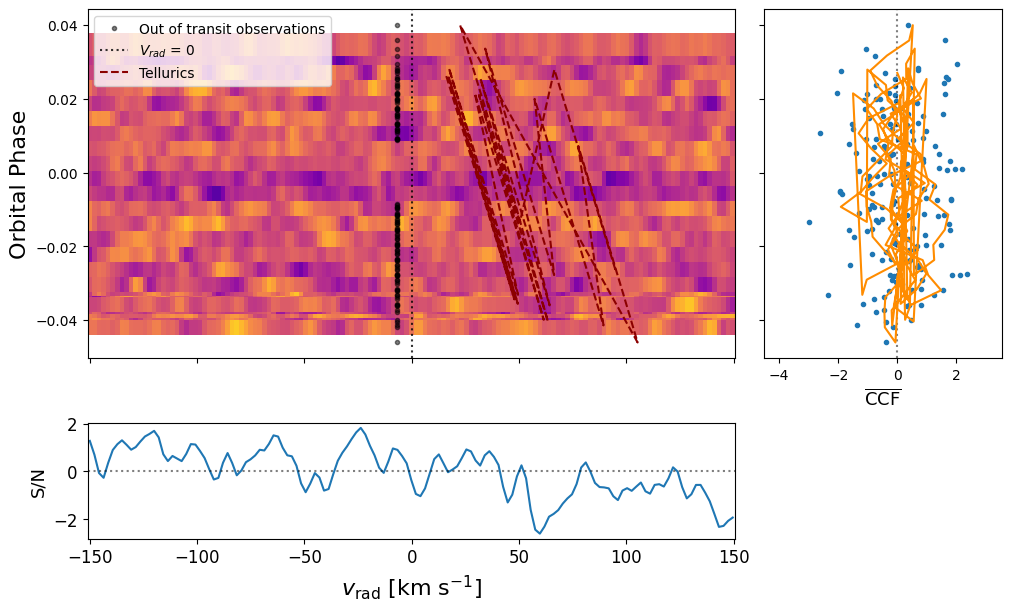

(array([52, 53, 54]),)
In-transit t-val = 1.98 / p-val 5.02e-02 / sig = 1.64
Out-of-transit t-val = -1.56 / p-val 1.19e-01 / sig = 1.18
T-val : Max value = 2.4 // Max position = -7.4
Histogram for Kp = 83.08 and RV = -6.62


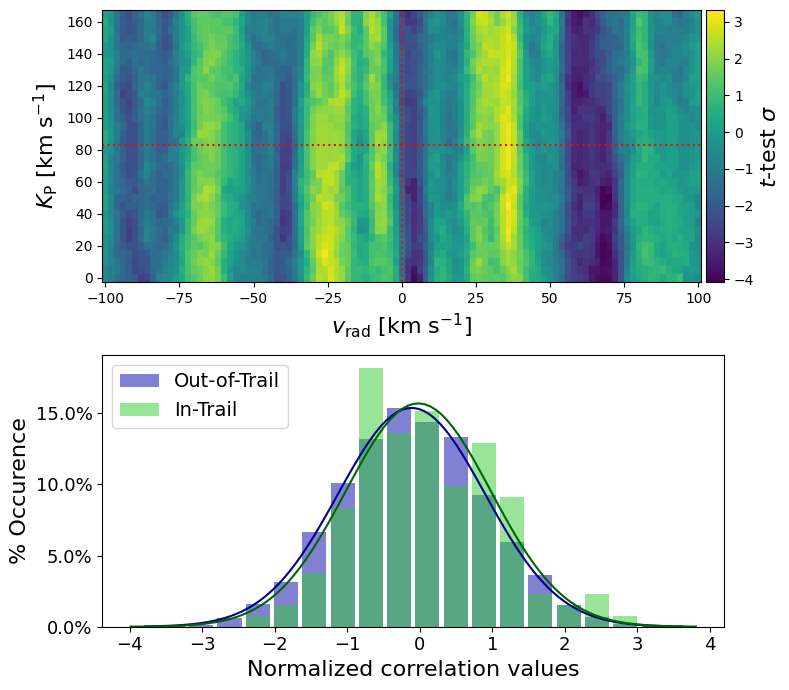

<Figure size 640x480 with 0 Axes>

2.106907595406499 0.03694301383109488 1.7873184873870067
/scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/Combined/injected_CO2_v05_at-75_scaling3000/combined_corr_nights1-2-3-4-5-6-7-8-9-10-11_pc0-0-0-0-0-0-0-0-0-0-0_mask_wings97-97-97-97-97-97-97-97-97-97-97_CO2_v05_data_info.npz


In [63]:
# Indices of orders that should not be used in the plots
orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]]

#-------------------------------------------------------------------------------------#

# Where to output the combined correlations
output_dir_comb = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/Combined/{reduction}')
output_dir_comb.mkdir(parents=True, exist_ok=True)  # create directory it if it doesn't exist

# Figures directory
fig_dir_comb = str(output_dir_comb) + "/Figures/"
Path(fig_dir_comb).mkdir(parents=True, exist_ok=True)

# Create filename for combined correlation file
args_filename = []
        
for i in range(len(file_arr)):
    args_filename.append((str(visit_dict[str(i + 1)].params[5]), str(int(visit_dict[str(i + 1)].params[1] * 100))))

args_filename = ['-'.join(values) for values in zip(*args_filename)]
filename = 'combined_corr_nights{}'.format(all_visits_str) + '_pc{}_mask_wings{}_'.format(*args_filename) + f"{model_name}"


idx_orders = np.arange(obs.nord)  # array of orders

# Remove each element of orders_to_delete from array of orders
for elem in orders_to_delete:
    idx_orders = np.setdiff1d(idx_orders, elem)


# Generate Kp 
Kp_array = np.array([obs.Kp.value]) 

ccf_map = np.concatenate(combined_ccf)
logl_map = np.concatenate(combined_logl)

ccf_obj, logl_obj = cc.plot_ccflogl(all_visits, 
                                    ccf_map,
                                    logl_map,
                                    corrRV0, Kp_array, [nPC],
                                    orders=idx_orders,
                                    path_fig=fig_dir_comb,
                                    fig_name=filename
                                   )

ccf_obj.ttest_map(all_visits, kind='logl', vrp=np.zeros_like(all_visits.vrp), orders=idx_orders, kp0=0,
                  RV_limit=100, kp_step=5, rv_step=2, RV=None, speed_limit=3, icorr=all_visits.iIn, equal_var=False)


# Save combined correlation
pl_obs.save_sequences(filename, visit_dict, [int(all_visits_str.replace("-", ""))], path=output_dir_comb)

In [ ]:
# After this notebook, git commit